In [11]:
# install.packages("geojsonio")
library(geojsonio)

# remotes::install_github("riatelab/osrm")
library(osrm)
packageVersion('osrm')
library(sf)


[1] '4.2.0'

In [3]:

pharmacy <- st_read(system.file("gpkg/apotheke.gpkg", package = "osrm"), 
                    quiet = TRUE)
travel_time <- osrmTable(loc = pharmacy)
travel_time$durations[1:5,1:5]


diag(travel_time$durations) <- NA
median(travel_time$durations, na.rm = TRUE)


,1,2,3,4,5
1,0.0,22.6,34.7,21.1,11.3
2,23.2,0.0,42.4,15.8,20.0
3,34.3,40.9,0.0,30.9,27.8
4,20.6,15.2,30.1,0.0,12.9
5,10.4,20.2,27.3,12.6,0.0


[1] 21.8

,src,dst,duration,distance,geometry
,<chr>,<chr>,<dbl>,<dbl>,<LINESTRING [m]>
1_2,1,2,22.56167,13.4092,LINESTRING (-13170.51 58410...


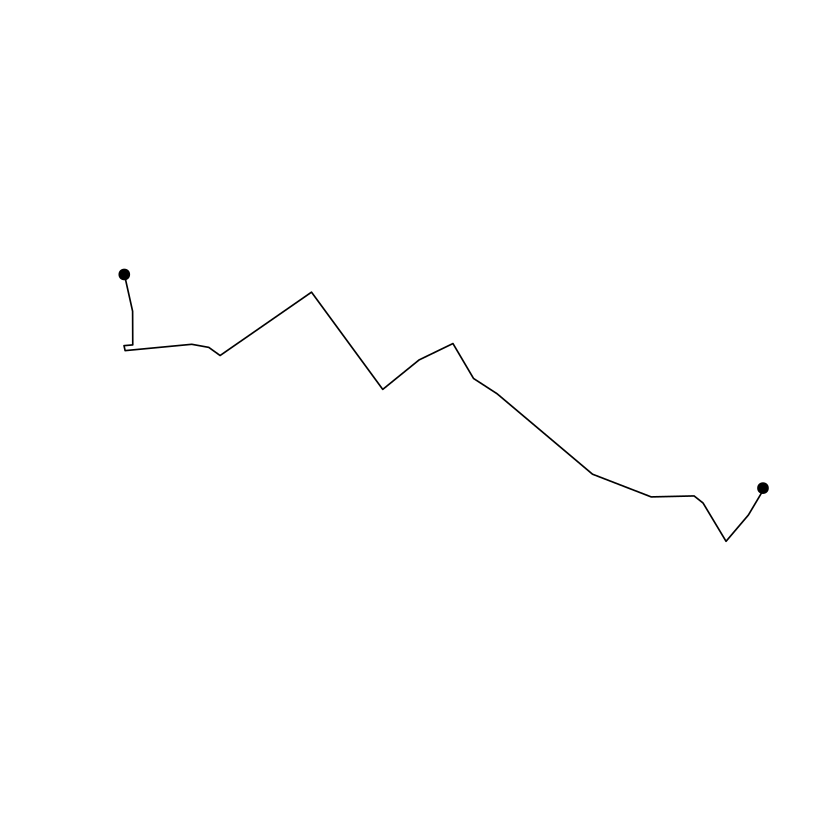

In [14]:
## shortest route between two points
(route <- osrmRoute(src = pharmacy[1, ], dst = pharmacy[2, ]))
plot(st_geometry(route))
plot(st_geometry(pharmacy[1:2,]), pch = 20, add = T, cex = 1.5)


In [27]:
# Create an interactive map
library(leaflet)
library(htmlwidgets)
library(IRdisplay)

str(route)

d <- route[1] %>%   st_transform(., 4326)

# plot(d)

m <- d %>% 
  # st_geometry() %>%
  leaflet() %>%
  addProviderTiles("CartoDB.Positron") %>% 
  addPolylines(color = "green")

# saveWidget(m, 'demo.html', selfcontained = TRUE)
# display_html('<iframe src="demo.html"></iframe>')

Classes 'sf' and 'data.frame':	1 obs. of  5 variables:
 $ src     : chr "1"
 $ dst     : chr "2"
 $ duration: num 22.6
 $ distance: num 13.4
 $ geometry:sfc_LINESTRING of length 1; first list element:  'XY' num [1:21, 1:2] -13171 -13052 -13050 -13177 -13161 ...
 - attr(*, "sf_column")= chr "geometry"
 - attr(*, "agr")= Factor w/ 3 levels "constant","aggregate",..: NA NA NA NA
  ..- attr(*, "names")= chr [1:4] "src" "dst" "duration" "distance"


,start,end,duration,distance,geometry
,<chr>,<chr>,<dbl>,<dbl>,<LINESTRING [m]>
1,1,2,22.56167,13.4092,LINESTRING (-13170.77 58410...
2,2,4,15.76000,8.4493,LINESTRING (-3875.322 58379...
3,4,3,30.09167,18.1688,LINESTRING (-7444.513 58427...
4,3,5,27.76500,16.4463,LINESTRING (-8024.73 585621...
5,5,1,10.41833,4.2443,LINESTRING (-11716.82 58435...


,id,distance,geometry
,<chr>,<dbl>,<POINT [°]>
loc,loc,439,POINT (13.39671 52.46661)


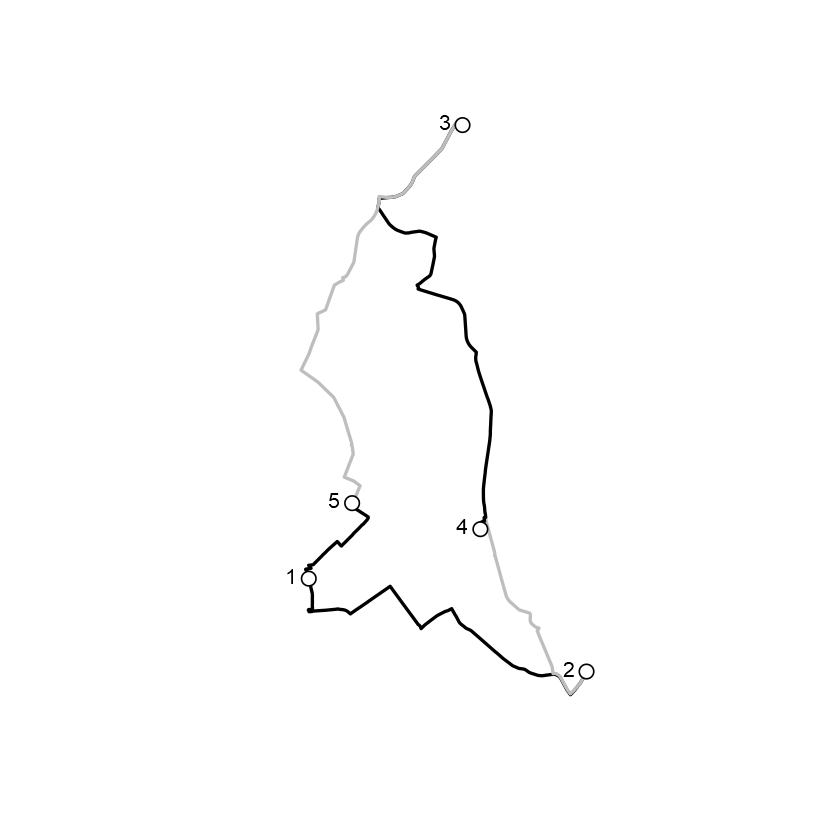

In [17]:
## shortest trip between a set of unordered points
(trips <- osrmTrip(loc = pharmacy[1:5, ], overview = "full"))
mytrip <- trips[[1]]$trip
# Display the trip
plot(st_geometry(mytrip), col = c("black", "grey"), lwd = 2)
plot(st_geometry(pharmacy[1:5, ]), cex = 1.5, pch = 21, add = TRUE)
text(st_coordinates(pharmacy[1:5,]), labels = row.names(pharmacy[1:5,]), 
     pos = 2)



## the nearest point on the street network from any point
pt_not_on_street_network <- c(13.40, 52.47)
(pt_on_street_network <- osrmNearest(loc = pt_not_on_street_network))

,id,isomin,isomax,geometry
,<int>,<dbl>,<dbl>,<MULTIPOLYGON [°]>
1,1,0,4,MULTIPOLYGON (((13.43743 52...
2,2,4,6,MULTIPOLYGON (((13.42321 52...
3,3,6,8,MULTIPOLYGON (((13.42257 52...
4,4,8,10,MULTIPOLYGON (((13.42257 52...
5,5,10,12,MULTIPOLYGON (((13.42257 52...


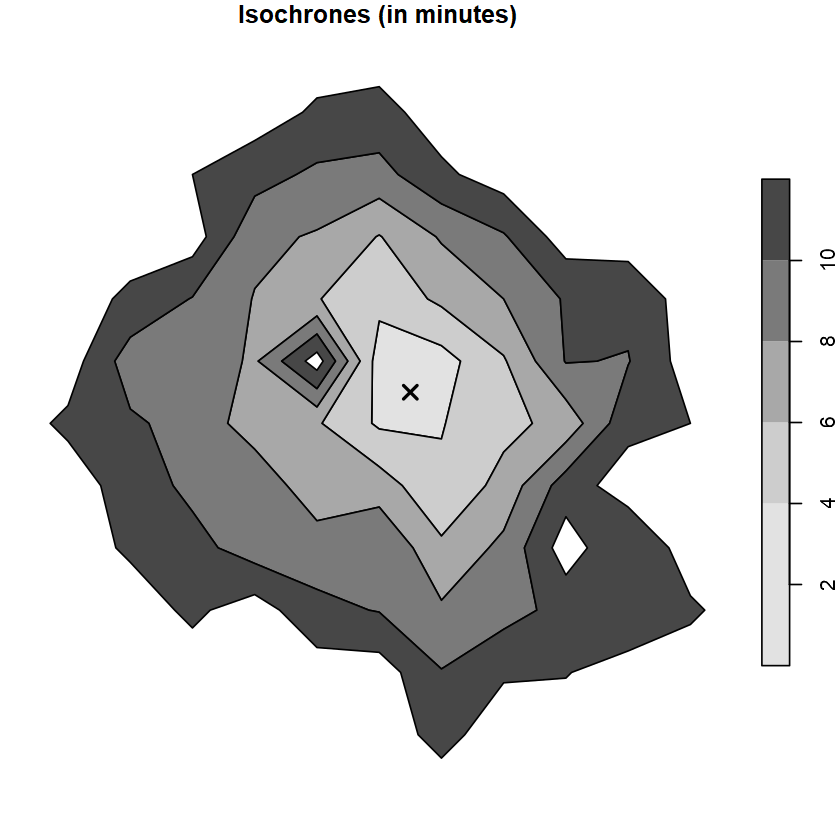

In [28]:
## reachable within a given time span from a point and returns the reachable regions as polygons
(iso <- osrmIsochrone(loc = c(13.43,52.47), breaks = seq(0,12,2)))


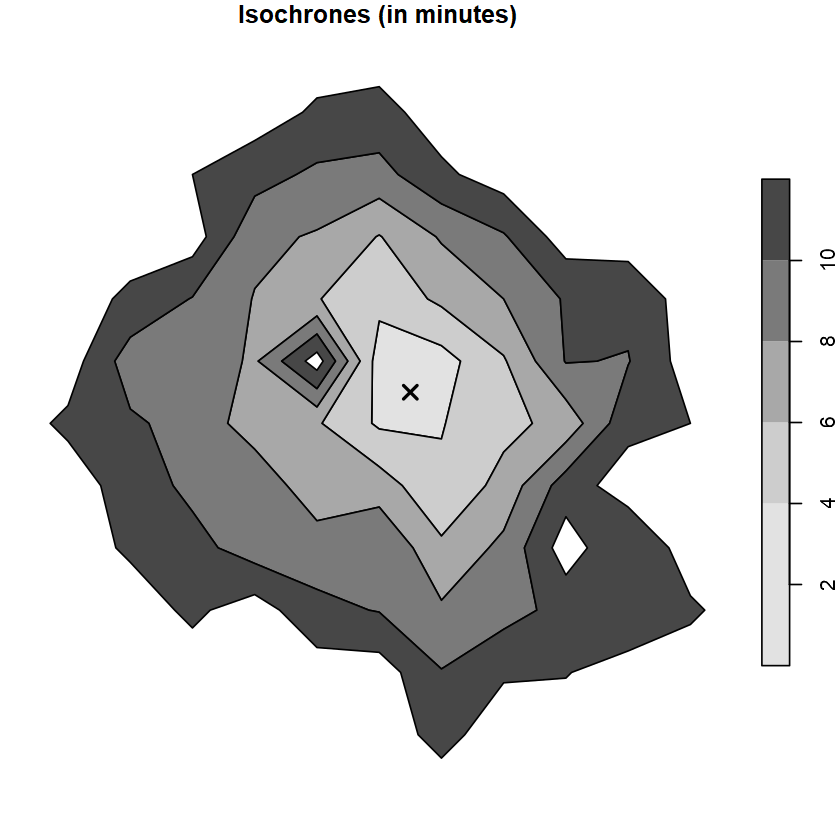

In [29]:

bks <-  sort(unique(c(iso$isomin, iso$isomax)))
pals <- hcl.colors(n = length(bks) - 1, palette = "Light Grays", rev = TRUE)
plot(iso["isomax"], breaks = bks, pal = pals, 
     main = "Isochrones (in minutes)", reset = FALSE)
points(x = 13.43, y = 52.47, pch = 4, lwd = 2, cex = 1.5)


# iso["isomax"] %>% st_transform(., 4326) %>%
#   # st_geometry() %>%
#   leaflet() %>%
#   addProviderTiles("CartoDB.Positron") %>% 
#   addPolygons(color = "green")